# Neural Network Volatility Surface

We train one neural network per trading date. Each network maps log-moneyness and time to maturity to total implied variance. 


## 1. Imports

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from utils import vega

import warnings
warnings.filterwarnings("ignore")

## 2. Load and Prepare Data

In [3]:
df = pd.read_csv('clean_iv_surface_input.csv')
df['date'] = pd.to_datetime(df['date'])
df['expiry'] = pd.to_datetime(df['expiry'])
df['k'] = df['log_moneyness'] 
df['w'] = df['IV']**2 * df['T'] # total variance

df["vega"] = vega(
    df["underlying_price"],
    df["strike"],
    df["T"],
    df["IV"]
)

dates = sorted(df['date'].unique())

df['is_call'] = (df["option_type"] == 'call')*1
df.head()


,contract,option_type,strike,expiry,date,open,high,low,market_price,volume,...,moneyness,log_moneyness,lower_bound,upper_bound,violates_bounds,IV,k,w,vega,is_call
0,O:AAPL260513C00265000,call,265.0,2026-05-13,2026-05-12,29.26,29.84,29.26,29.84,13,...,0.898915,-0.106567,29.829007,294.799988,False,0.750314,-0.106567,0.001541,0.145430,1
1,O:AAPL260513C00272500,call,272.5,2026-05-13,2026-05-11,20.07,20.41,20.07,20.41,6,...,0.931051,-0.071441,20.239671,292.679993,False,0.543884,-0.071441,0.001620,1.707834,1
2,O:AAPL260513C00277500,call,277.5,2026-05-13,2026-05-11,14.78,15.60,13.56,15.60,13,...,0.948135,-0.053259,15.240766,292.679993,False,0.503267,-0.053259,0.001387,2.999522,1
3,O:AAPL260513C00282500,call,282.5,2026-05-13,2026-05-12,10.72,12.60,10.60,12.60,109,...,0.958277,-0.042619,12.330924,294.799988,False,0.558413,-0.042619,0.000854,2.067533,1
4,O:AAPL260513C00285000,call,285.0,2026-05-13,2026-05-11,7.20,8.75,6.10,7.96,341,...,0.973760,-0.026591,7.742409,292.679993,False,0.263341,-0.026591,0.000380,3.308746,1


## 3. Define Neural Network Architecture

In [4]:
class VolSurfaceNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 32),
            nn.SiLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

## 4. Train One Neural Network Per Date

In [5]:
all_nn_models = {}
all_nn_objects = {}


features = ["log_moneyness", "T", "is_call"]
target = "w"

for date in dates:

    # -----------------------------
    # 1. Features and target
    # -----------------------------

    today_df = df[df["date"] == date].copy()

    X = today_df[features].values
    y = today_df[target].values.reshape(-1, 1)

    # -----------------------------
    # 2. Train Test split
    # -----------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_s = x_scaler.fit_transform(X_train)
    X_test_s = x_scaler.transform(X_test)

    y_train_s = y_scaler.fit_transform(y_train)
    y_test_s = y_scaler.transform(y_test)

    X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_s, dtype=torch.float32)

    X_test_t = torch.tensor(X_test_s, dtype=torch.float32)
    y_test_t = torch.tensor(y_test_s, dtype=torch.float32)

    model = VolSurfaceNN()

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn = nn.MSELoss()

    # -----------------------------
    # 3. Train
    # -----------------------------
    n_epochs = 900

    for epoch in range(n_epochs):
        model.train()

        pred = model(X_train_t)
        loss = loss_fn(pred, y_train_t)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 300 == 0:
            model.eval()
            with torch.no_grad():
                test_pred = model(X_test_t)
                test_loss = loss_fn(test_pred, y_test_t)


    # -----------------------------
    # 4. Predict w's
    # -----------------------------
    model.eval()

    with torch.no_grad():
        pred_test_s = model(X_test_t).numpy()

    pred_test_w = y_scaler.inverse_transform(pred_test_s)
    true_test_w = y_scaler.inverse_transform(y_test_s)

    rmse = np.sqrt(np.mean((pred_test_w - true_test_w) ** 2))
    mae = np.mean(np.abs(pred_test_w - true_test_w))

    all_nn_models[date] ={
        "model": model,
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
    }

    all_nn_objects[str(date)] = {
        "state_dict": model.state_dict(),
        "x_scaler": x_scaler,
        "y_scaler": y_scaler
    }


# Save dict's

torch.save(all_nn_objects, "all_nn_objects.pt")
torch.save(all_nn_models, "all_nn_models.pt")


In [6]:
# Load everything without running the previous cell


all_nn_objects = torch.load(
    "all_nn_objects.pt",
    map_location="cpu",
    weights_only=False
)

all_nn_models = {}

for date, obj in all_nn_objects.items():
    model = VolSurfaceNN()
    model.load_state_dict(obj["state_dict"])
    model.eval()

    all_nn_models[date] = {
        "model": model,
        "x_scaler": obj["x_scaler"],
        "y_scaler": obj["y_scaler"]
    }


## 5. Define 'nn_iv'

In [7]:
def nn_iv(date,k, T, S0, is_call = True):
    """
    Predict implied volatility from the trained neural network.

    Parameters
    ----------
    k : float
        Log-moneyness
    T : float
        Time to maturity (years)
    S0 : float
        Current underlying price
    is_call : int
        1 for call, 0 for put

    Returns
    -------
    float
        Predicted implied volatility
    """

    obj = all_nn_models[date]

    model = obj["model"]
    x_scaler = obj["x_scaler"]
    y_scaler = obj["y_scaler"]
    

    if is_call == True:
        x = np.array([[k, T, 1]])
    else: x = np.array([k,T,0])
    
    x = x_scaler.transform(x)
    x = torch.tensor(x, dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        pred = model(x).numpy()

    w = max(y_scaler.inverse_transform(pred)[0, 0], 1e-10)
    T = max(T,1e-8)
    iv = np.sqrt(w / T)

    return float(iv)

# 6. Visual Comparison with Market Data and Smiles

In [8]:
day = str(dates[2])


day_df = df[(df["date"] == day) & (df['option_type'] == 'call')][["option_type", "strike" ,"k", "T", "underlying_price", "IV", "market_price"]].copy()

day_df["nn_iv"] = day_df.apply(
    lambda row: nn_iv(
        day,
        row["k"],
        row["T"],
        row["underlying_price"],
        is_call = 1
    ),
    axis=1,
)

day_df.head()

,option_type,strike,k,T,underlying_price,IV,market_price,nn_iv
59,call,265.0,-0.120279,0.005476,298.869995,0.635983,33.95,0.942186
61,call,267.5,-0.110889,0.005476,298.869995,0.981360,31.99,0.884569
65,call,272.5,-0.092370,0.005476,298.869995,0.701543,26.65,0.770857
68,call,275.0,-0.083238,0.005476,298.869995,0.669601,24.20,0.715144
71,call,277.5,-0.074188,0.005476,298.869995,0.663273,21.83,0.660500


In [9]:
def plot_surface_with_market(df, column, title):

    fig = plt.figure(figsize=(9,7))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_trisurf(
        df["k"],
        df["T"],
        df[column],
        cmap="viridis",
        alpha=0.7
    )

    ax.scatter(
        df["k"],
        df["T"],
        df["IV"],
        color="red",
        s=20,
        label="Market"
    )

    ax.set_xlabel("Log-moneyness")
    ax.set_ylabel("T")
    ax.set_zlabel("IV")
    ax.legend()
    ax.set_title(title)

    plt.show()

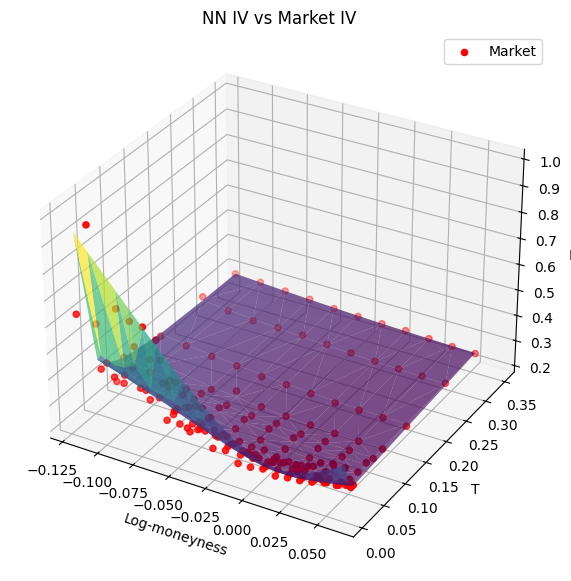

In [10]:
plot_surface_with_market(day_df, "nn_iv", "NN IV vs Market IV")

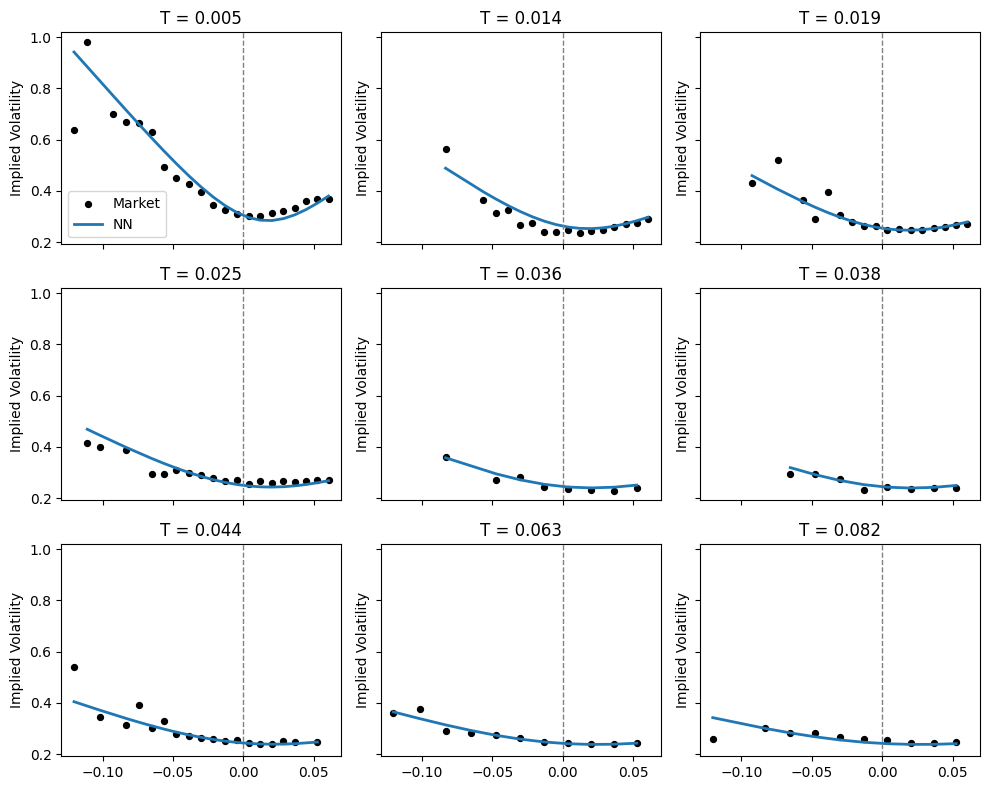

In [11]:
maturities = np.sort(day_df["T"].unique())
maturities = maturities[:9]

fig, axes = plt.subplots(3, 3, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, T in zip(axes, maturities):

    temp = (
        day_df[day_df["T"] == T]
        .sort_values("k")
    )

    ax.scatter(
        temp["k"],
        temp["IV"],
        color="black",
        s=18,
        label="Market"
    )

    ax.plot(
        temp["k"],
        temp["nn_iv"],
        lw=2,
        label="NN"
    )

    ax.set_title(f"T = {T:.3f}")

    ax.set_ylabel("Implied Volatility")

    ax.axvline(
        0,
        color="gray",
        linestyle="--",
        linewidth=1
    )

axes[0].legend()


plt.tight_layout()
plt.show()

# 7. Calibration Performance

In [13]:
rmse = {}
rmse_vega = {}
bucket_errors = {}

for date in dates:

    date_df = df[df["date"] == date][["option_type","strike" ,"k", "T", "underlying_price", "vega", "IV", "market_price"]].copy()

    date_df["nn_iv"] = date_df.apply(
        lambda row: nn_iv(str(date), row["k"], row["T"], row["underlying_price"]),
        axis=1,
    )


    err2 = (date_df["nn_iv"] - date_df["IV"]) ** 2

    rmse[date] = np.sqrt(np.mean(err2))

    rmse_vega[date] = np.sqrt(
        np.average(err2, weights=date_df["vega"])
    )

    date_df["moneyness_bucket"] = pd.cut(
        date_df["k"].abs(),
        bins=[0, 0.05, 0.1, np.inf],
        labels=["ATM", "Near-wing", "Far-wing"]
    )

    bucket_rmse = date_df.groupby("moneyness_bucket").apply(
        lambda x: np.sqrt(np.mean((x["nn_iv"] - x["IV"]) ** 2))
    )

    bucket_errors[date] = bucket_rmse

results_df = pd.DataFrame({
    "date": rmse.keys(),
    "rmse": rmse.values(),
    "vega_rmse": rmse_vega.values(),
})

bucket_df = (
    pd.DataFrame(bucket_errors)
      .T
      .reset_index()
      .rename(columns={"index": "date"})
)

results_df = results_df.merge(bucket_df, on="date", how="left")

results_df.drop(columns="date").mean()

rmse         0.092815
vega_rmse    0.041930
ATM          0.054639
Near-wing    0.104279
Far-wing     0.146307
dtype: float64